##Final Findings & Recommendations
###Executive Summary

This investigation analysed 2,920 operational records across four oil and gas depots over a 12-month period to identify the primary drivers of throughput reduction.

The analysis followed a structured operational diagnostics approach:

Data quality validation
Exploratory Data Analysis (EDA)
Anomaly detection
Bivariate analysis
Drill-down investigation
Pareto analysis
Root cause identification

The objective was not only to identify where throughput declined, but also to determine the operational factors contributing to the performance gap.


####Key Findings
1. Throughput Performance Was Concentrated Around a Specific Operational Issue

Initial throughput analysis showed that most operations performed within a normal production range of approximately 900–1,050 barrels.

However, a separate lower-performance cluster was identified around 500–700 barrels, indicating that throughput losses were not random variation but were associated with specific operational conditions.

2. Nairobi Depot Was the Primary Area of Underperformance

Comparison of throughput across depots revealed significant performance differences.

Nairobi showed substantially lower typical throughput compared with Mombasa, Kisumu, and Eldoret.

This indicated that the production issue was not network-wide but concentrated within a specific operational location.

3. NBI-P03 Was the Dominant Contributor to Production Losses

Further drill-down analysis identified NBI-P03 as the main contributor to Nairobi's throughput decline.

Key evidence:

NBI-P03 median throughput: approximately 628 barrels
Other Nairobi machines: approximately 1,030 barrels

Pareto analysis confirmed that:

NBI-P03 accounted for approximately 93% of all low-throughput events.

This indicates that the production problem is highly concentrated around a single operational asset.

4. Maintenance Degradation Was the Main Performance Driver

Investigation of maintenance conditions showed a strong relationship between maintenance issues and reduced throughput.

For NBI-P03:

Condition	Median Throughput
No maintenance issue	~1,057 barrels
Maintenance issue present	~626 barrels

This represents an approximate 41% reduction in typical throughput during maintenance-affected periods.

Additionally:

Missed maintenance accounted for approximately 88% of low-throughput events.


###Root Cause Conclusion

The analysis indicates that the primary driver of throughput losses was:

Maintenance-related degradation affecting the NBI-P03 production asset at Nairobi depot.

The issue appears to have emerged from February onward, when NBI-P03 transitioned from normal operating performance to a sustained lower-throughput state.

The evidence suggests that improving NBI-P03 maintenance reliability represents the highest-impact opportunity for recovering lost production capacity.


###Recommendations
1. Prioritise NBI-P03 Recovery

Objective: Restore the machine to normal production capability.

Actions:

Conduct a detailed technical inspection of NBI-P03.
Identify underlying equipment failures contributing to repeated maintenance events.
Perform corrective maintenance and verify throughput recovery after intervention.

Expected impact:

Recover the largest identified source of production losses.

2. Strengthen Preventive Maintenance Controls

Objective: Prevent repeated degradation events.

Actions:

Improve maintenance scheduling discipline.
Track overdue maintenance activities.
Introduce maintenance compliance KPIs.
Review whether current maintenance intervals are sufficient.

Expected impact:

Reduce recurrence of maintenance-driven production interruptions.

3. Implement Early Warning Monitoring

Objective: Detect performance degradation before significant losses accumulate.

Actions:

Create operational alerts such as:

Throughput dropping below expected thresholds.
Repeated maintenance flags.
Sudden machine performance changes.

Example:

Trigger investigation when NBI-P03 throughput remains below 800 barrels for multiple consecutive shifts.

Expected impact:

Move from reactive maintenance toward proactive operational management.


###Business Impact Summary

The analysis demonstrates that operational analytics can transform a broad production concern into a targeted intervention.

Instead of applying resources across the entire network, the evidence identifies:

Where: Nairobi depot
Which asset: NBI-P03
What issue: Maintenance-related degradation
Priority action: Restore equipment reliability

This enables operations teams to focus resources where they can create the greatest improvement in production performance.

###Analytical Reflection

This project demonstrates the role of an operational analyst:

The goal is not simply to identify what happened. The goal is to explain why it happened, quantify its impact, and recommend the action that creates the highest business value.


1. Data Validation and Profiling

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Inuka internship projects/week 5 diagnostics analysis/Mystery_Ops.csv")

df.head()

,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260224-MOM-D,24/02/2026,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none
1,MO-20261015-KIS-D,15/10/2026,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none
2,MO-20260518-MOM-D,18/05/2026,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none
3,MO-20260209-MOM-N,09/02/2026,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none
4,MO-20260318-MOM-N,18/03/2026,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none


In [4]:
df.shape

(2920, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           2920 non-null   object 
 1   operation_date      2920 non-null   object 
 2   depot               2920 non-null   object 
 3   shift               2920 non-null   object 
 4   operator_id         2902 non-null   object 
 5   machine_id          2920 non-null   object 
 6   throughput_barrels  2915 non-null   float64
 7   temperature_c       2900 non-null   float64
 8   maintenance_flag    2920 non-null   int64  
 9   voltage_count       2920 non-null   int64  
 10  incident_type       2920 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 251.1+ KB


In [6]:
df["operation_date"] = pd.to_datetime(
    df["operation_date"],
    format="%d/%m/%Y"
)

In [7]:
df["operation_date"].dtype

dtype('<M8[ns]')

In [8]:
df.isna().sum()

,0
record_id,0
operation_date,0
depot,0
shift,0
operator_id,18
machine_id,0
throughput_barrels,5
temperature_c,20
maintenance_flag,0
voltage_count,0


In [9]:
df.duplicated(
    subset=["operation_date", "depot", "shift"]
).sum()

np.int64(0)

In [10]:
df.describe()

,operation_date,throughput_barrels,temperature_c,maintenance_flag,voltage_count
count,2920,2915.000000,2900.000000,2920.000000,2920.000000
mean,2026-07-02 00:00:00,916.891149,25.050310,0.186644,221.122945
min,2026-01-01 00:00:00,296.500000,10.900000,0.000000,197.000000
25%,2026-04-02 00:00:00,872.850000,21.200000,0.000000,217.000000
50%,2026-07-02 00:00:00,969.300000,25.100000,0.000000,221.000000
75%,2026-10-01 00:00:00,1029.650000,29.100000,0.000000,225.000000
max,2026-12-31 00:00:00,1210.600000,39.900000,1.000000,242.000000
std,NaN,168.122566,5.567664,0.389692,6.518187


#Univariate Analysis


In [11]:
df.nunique()

,0
record_id,2920
operation_date,365
depot,4
shift,2
operator_id,15
machine_id,13
throughput_barrels,2082
temperature_c,266
maintenance_flag,2
voltage_count,44


In [12]:
df["depot"].value_counts()

,count
depot,
Mombasa,730
Kisumu,730
Nairobi,730
Eldoret,730


In [13]:
df["shift"].value_counts()

,count
shift,
Day,1460
Night,1460


In [14]:
df["maintenance_flag"].value_counts()

,count
maintenance_flag,
0,2375
1,545


In [15]:
df["incident_type"].value_counts()

,count
incident_type,
none,2332
missed_maintenance,529
brief_equipment_fault,30
operator_blunder,29


In [16]:
df["operator_id"].value_counts(dropna=False)

,count
operator_id,
OP-E02,253
OP-K01,248
OP-K03,243
OP-E03,237
OP-E01,235
OP-K02,233
OP-M02,194
OP-M03,183
OP-M04,175


In [17]:
df["machine_id"].value_counts(dropna=False)

,count
machine_id,
NBI-P03,566
ELD-P01,255
KSM-P03,251
KSM-P01,250
MBA-P01,244
MBA-P02,244
MBA-P03,242
ELD-P02,241
ELD-P03,234


In [18]:
df[df["operator_id"].isna()]

,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
421,MO-20260611-KIS-D,2026-06-11,Kisumu,Day,NaN,KSM-P01,1101.0,28.5,0,221,none
426,MO-20260129-NAI-D,2026-01-29,Nairobi,Day,NaN,NBI-P02,1080.2,30.2,0,221,none
509,MO-20260212-ELD-D,2026-02-12,Eldoret,Day,NaN,ELD-P01,1032.8,22.4,0,222,none
671,MO-20261021-MOM-D,2026-10-21,Mombasa,Day,NaN,MBA-P01,975.0,29.3,0,230,none
921,MO-20260728-ELD-D,2026-07-28,Eldoret,Day,NaN,ELD-P01,994.7,12.9,0,225,none
1081,MO-20260321-MOM-D,2026-03-21,Mombasa,Day,NaN,MBA-P01,1160.5,34.8,0,229,none
1144,MO-20260706-ELD-D,2026-07-06,Eldoret,Day,NaN,ELD-P03,970.6,20.2,0,223,none
1751,MO-20260803-MOM-N,2026-08-03,Mombasa,Night,NaN,MBA-P01,987.4,27.1,0,223,none
2081,MO-20260511-ELD-D,2026-05-11,Eldoret,Day,NaN,ELD-P02,986.2,19.0,0,225,none
2094,MO-20261220-MOM-D,2026-12-20,Mombasa,Day,NaN,MBA-P03,1142.4,30.7,0,219,none


In [19]:
df[df["operator_id"].isna()]["shift"].value_counts()

,count
shift,
Day,13
Night,5


Missing operator IDs are slightly more frequent during Day shift, but the volume is small. This does not currently represent a major data-quality concern.

In [20]:
df[df["operator_id"].isna()]["depot"].value_counts()

,count
depot,
Kisumu,6
Eldoret,5
Mombasa,5
Nairobi,2


Missing operator information is slightly higher in Kisumu, Eldoret and Mombasa, but the differences are small and distributed across the network.

In [21]:
pd.crosstab(
    df["depot"],
    df["machine_id"]
)

machine_id,ELD-P01,ELD-P02,ELD-P03,KSM-P01,KSM-P02,KSM-P03,MBA-P01,MBA-P02,MBA-P03,NBI-P01,NBI-P02,NBI-P03,NBI-P04
depot,,,,,,,,,,,,,
Eldoret,255,241,234,0,0,0,0,0,0,0,0,0,0
Kisumu,0,0,0,250,229,251,0,0,0,0,0,0,0
Mombasa,0,0,0,0,0,0,244,244,242,0,0,0,0
Nairobi,0,0,0,0,0,0,0,0,0,66,51,566,47


Data quality checks confirmed no exact duplicate records and validated the relationship between depot and machine identifiers. Missing operator records were limited to 18 observations (<1% of the dataset) and distributed across shifts and depots, suggesting minor recording gaps rather than systematic failure. Machine identifiers aligned correctly with their associated depots, increasing confidence in location-based operational analysis.

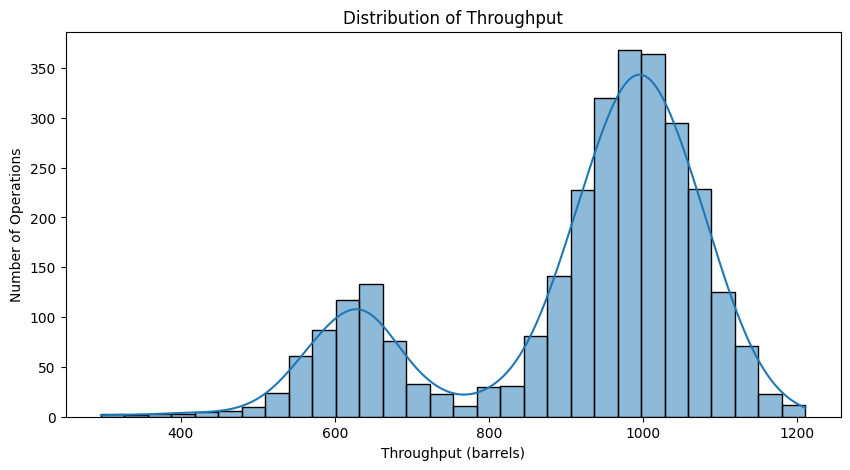

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="throughput_barrels",
    bins=30,
    kde=True
)

plt.title("Distribution of Throughput")
plt.xlabel("Throughput (barrels)")
plt.ylabel("Number of Operations")

plt.show()

The throughput distribution shows that most operational observations are concentrated around approximately 900–1,050 barrels, indicating the typical production range for normal operations.

However, the distribution is not completely symmetrical. A second smaller concentration appears around approximately 600–700 barrels, suggesting the presence of a lower-performing operational state rather than random variation alone.

This separation between the main production cluster and the lower-throughput cluster indicates that some operational conditions may be causing significant reductions in output. Potential explanations include equipment issues, maintenance events, shift-related factors, or specific machine behaviour, which will be investigated in later diagnostic analysis.

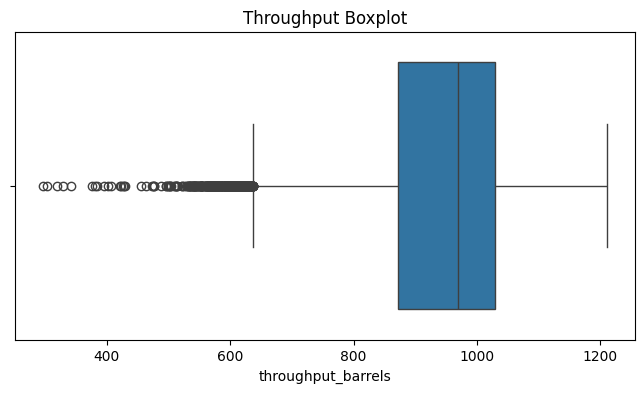

In [23]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="throughput_barrels"
)

plt.title("Throughput Boxplot")

plt.show()

The boxplot confirms that throughput contains several observations significantly below the normal operating range. Most observations fall within the central throughput band, but a large number of lower-end observations are identified as statistical outliers.

These observations should not immediately be removed, as they may represent genuine operational failures rather than data errors. Further investigation is required to determine whether these low-throughput events are associated with specific depots, machines, shifts, or incident types.

In [24]:
Q1 = df["throughput_barrels"].quantile(0.25)

Q3 = df["throughput_barrels"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR


outliers = df[
    (df["throughput_barrels"] < lower_bound) |
    (df["throughput_barrels"] > upper_bound)
]

outliers.shape

(350, 11)

In [25]:
outliers.head()


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
12,MO-20260402-ELD-N,2026-04-02,Eldoret,Night,OP-E02,ELD-P02,531.5,27.4,0,221,brief_equipment_fault
25,MO-20260417-NAI-N,2026-04-17,Nairobi,Night,OP-N04,NBI-P03,422.8,28.8,1,222,brief_equipment_fault
57,MO-20260512-NAI-N,2026-05-12,Nairobi,Night,OP-N05,NBI-P03,536.2,25.3,1,223,missed_maintenance
59,MO-20260421-MOM-N,2026-04-21,Mombasa,Night,OP-M04,MBA-P01,572.9,30.6,0,214,operator_blunder
60,MO-20260815-NAI-N,2026-08-15,Nairobi,Night,OP-N01,NBI-P03,568.1,24.1,1,238,missed_maintenance


<Axes: xlabel='temperature_c', ylabel='Count'>

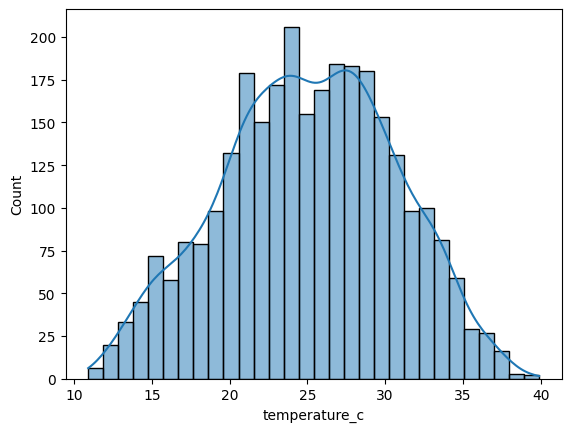

In [26]:
sns.histplot(
    data=df,
    x="temperature_c",
    bins=30,
    kde=True
)

Temperature appears to follow a relatively stable operational range with no obvious extreme anomalies requiring immediate investigation.

<Axes: xlabel='voltage_count', ylabel='Count'>

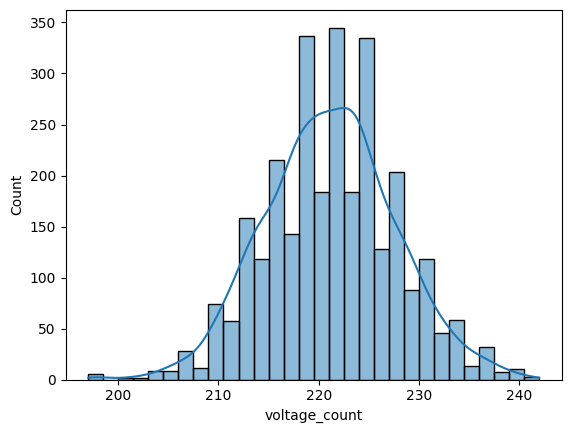

In [27]:
sns.histplot(
    data=df,
    x="voltage_count",
    bins=30,
    kde=True
)

#Bivariate EDA

###How to read a boxplot
Bottom of box = Q1 (25th percentile)

Line inside box = median (50th percentile)

Top of box = Q3 (75th percentile)

The circles - potential outliers

1. Throughput by Depot

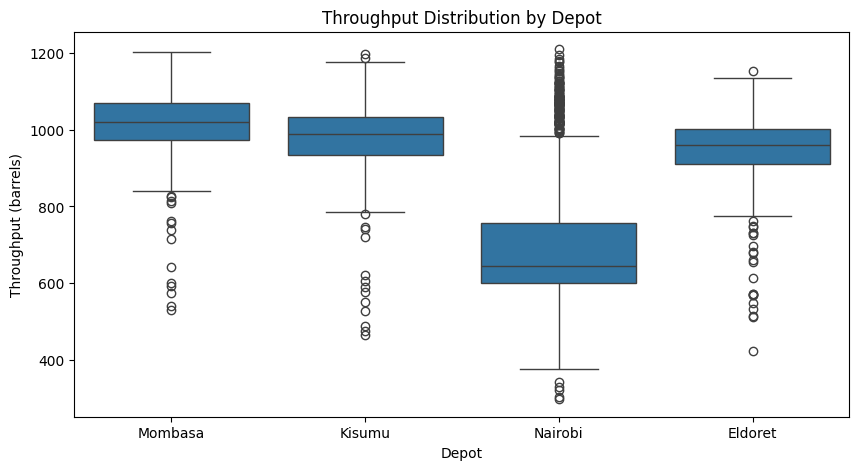

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="depot",
    y="throughput_barrels"
)

plt.title("Throughput Distribution by Depot")
plt.xlabel("Depot")
plt.ylabel("Throughput (barrels)")

plt.show()

Nairobi demonstrates substantially lower median throughput compared with the other depots, suggesting a location-specific operational issue requiring further investigation.

2. Throughput by Shift

<Axes: xlabel='shift', ylabel='throughput_barrels'>

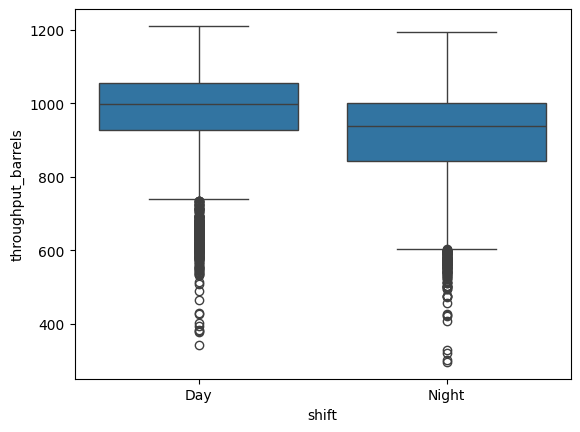

In [29]:
sns.boxplot(
    data=df,
    x="shift",
    y="throughput_barrels"
)

Day shift operations demonstrate slightly higher throughput compared with Night shift operations. Although the difference is not as significant as the depot-level variation, the result suggests that operating conditions during different shifts may influence production performance and should be considered during further drill-down analysis.

3. Throughput by Incident Type

<Axes: xlabel='incident_type', ylabel='throughput_barrels'>

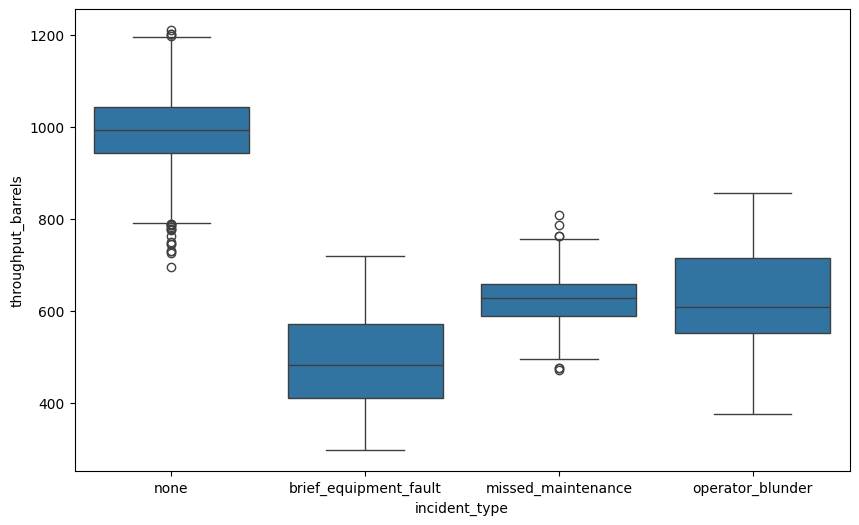

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="incident_type",
    y="throughput_barrels"
)

Incident type has a strong relationship with throughput performance. Operations without recorded incidents maintain the highest throughput levels, while equipment faults and operator-related issues are associated with significant production reductions. Equipment failures appear to represent the largest operational risk due to their association with the lowest throughput levels.

4. Throughput vs Maintenance Flag


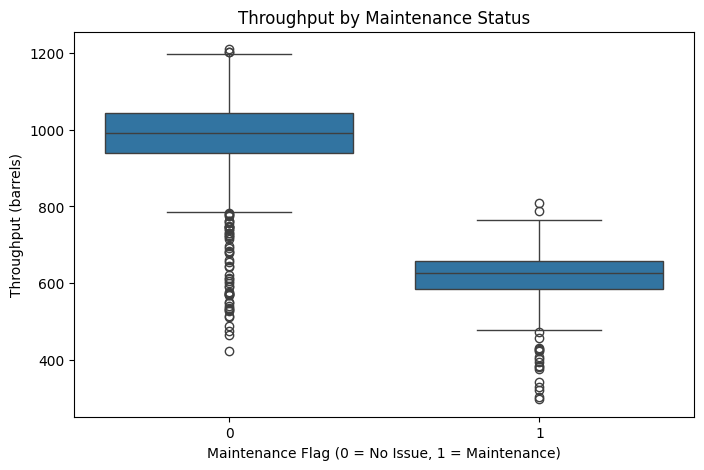

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="maintenance_flag",
    y="throughput_barrels"
)

plt.title("Throughput by Maintenance Status")
plt.xlabel("Maintenance Flag (0 = No Issue, 1 = Maintenance)")
plt.ylabel("Throughput (barrels)")

plt.show()

Records associated with maintenance issues show substantially lower throughput compared with normal operating conditions. This indicates that maintenance-related events are an important contributor to production losses. However, additional analysis is required to determine whether maintenance problems are concentrated around specific machines or locations.

5. Throughput by Machine

<Axes: xlabel='machine_id', ylabel='throughput_barrels'>

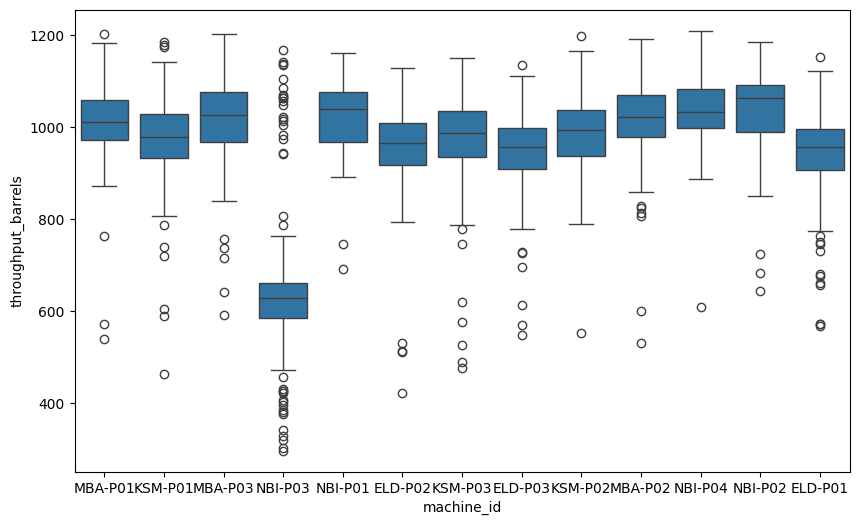

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="machine_id",
    y="throughput_barrels"
)

Machine-level analysis reveals significant variation in production performance. NBI-P03 demonstrates noticeably lower throughput compared with other machines and represents a potential contributor to Nairobi's reduced production. Due to its large number of observations, NBI-P03 should be investigated further alongside maintenance and incident records to determine whether equipment condition is driving the performance gap.

Next up numerical comparisons

For that we will use scatterplots


6. Temperature vs Throughput

<Axes: xlabel='temperature_c', ylabel='throughput_barrels'>

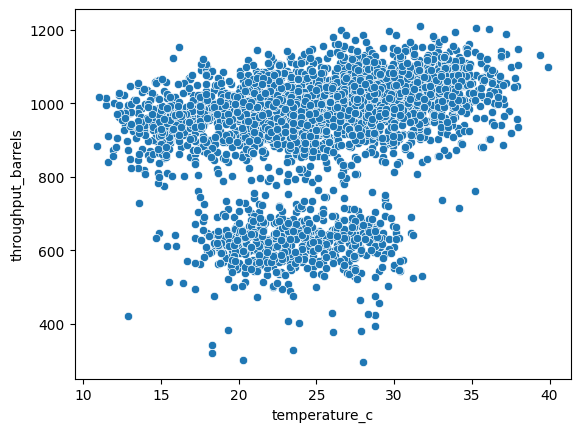

In [33]:
sns.scatterplot(
    data=df,
    x="temperature_c",
    y="throughput_barrels"
)

Temperature does not show a strong visible relationship with throughput. The scatter plot shows that both high and low throughput values occur across similar temperature ranges, suggesting that environmental temperature is unlikely to be the primary explanation for production losses.

7. Voltage vs Throughput

<Axes: xlabel='voltage_count', ylabel='throughput_barrels'>

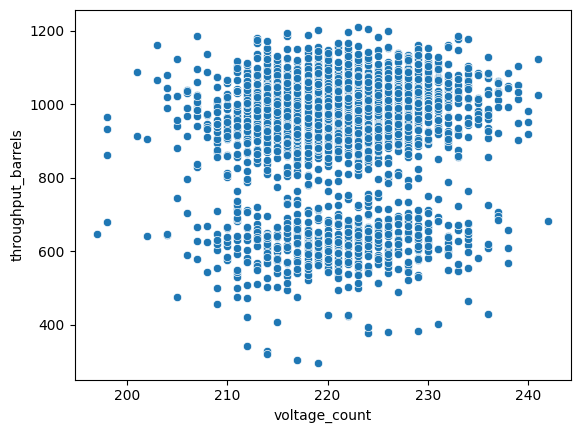

In [34]:
sns.scatterplot(
    data=df,
    x="voltage_count",
    y="throughput_barrels"
)

Voltage measurements show limited evidence of a direct relationship with throughput. Similar voltage levels appear across both normal and reduced production states, suggesting that electrical variation is unlikely to be the main driver of throughput reduction.

 ###Current Diagnostic Conclusion (Before Root Cause Analysis)

 Initial exploratory analysis indicates that throughput losses are concentrated primarily within Nairobi depot rather than being a network-wide issue. Nairobi shows significantly lower throughput compared with other depots, with NBI-P03 emerging as a potential contributor due to its lower median performance. Additionally, maintenance-related events and equipment failures are strongly associated with reduced throughput, suggesting that equipment reliability may be a key driver of production losses. Temperature and voltage do not show strong relationships with throughput, making environmental and electrical factors less likely explanations. Further drill-down analysis will focus on Nairobi, particularly NBI-P03, maintenance events, and incident patterns, to identify the underlying operational root cause.

#Drill-down Analysis

Since we have identified Nairobi as the main depot culprit, our drill down analysis will be around that

In [35]:
nairobi_df = df[
    df["depot"] == "Nairobi"
]

In [36]:
nairobi_df.groupby("machine_id")["throughput_barrels"].agg(
    ["count", "mean", "median"]
).sort_values(
    "median"
)

,count,mean,median
machine_id,,,
NBI-P03,566,633.113428,628.3
NBI-P04,47,1031.300000,1033.3
NBI-P01,66,1021.375758,1039.1
NBI-P02,51,1026.062745,1064.7


NBI-P03 has the highest number of observations, but it has the lowest throughput performance.

In [37]:
df.groupby("machine_id")["maintenance_flag"].mean()

,maintenance_flag
machine_id,
ELD-P01,0.000000
ELD-P02,0.000000
ELD-P03,0.000000
KSM-P01,0.000000
KSM-P02,0.000000
KSM-P03,0.000000
MBA-P01,0.000000
MBA-P02,0.000000
MBA-P03,0.000000


"NBI-P03 has 96% maintenance-flagged observations compared with 0% across other machines, and this coincides with a throughput reduction from ~1000 barrels to ~630 barrels."

In [38]:
pd.crosstab(
    df["machine_id"],
    df["incident_type"],
    normalize="index"
)


incident_type,brief_equipment_fault,missed_maintenance,none,operator_blunder
machine_id,,,,
ELD-P01,0.007843,0.000000,0.972549,0.019608
ELD-P02,0.008299,0.000000,0.983402,0.008299
ELD-P03,0.008547,0.000000,0.987179,0.004274
KSM-P01,0.012000,0.000000,0.980000,0.008000
KSM-P02,0.000000,0.000000,0.995633,0.004367
KSM-P03,0.015936,0.000000,0.980080,0.003984
MBA-P01,0.004098,0.000000,0.987705,0.008197
MBA-P02,0.004098,0.000000,0.991803,0.004098
MBA-P03,0.004132,0.000000,0.975207,0.020661


NBI-P03 is fundamentally different from the other machines. Almost all of its operational records are associated with missed maintenance incidents, whereas other machines rarely experience this condition.

In [39]:
nbi_p03 = df[df["machine_id"] == "NBI-P03"]

In [40]:
df[df["depot"]=="Nairobi"].groupby(
    ["machine_id","maintenance_flag"]
)["throughput_barrels"].agg(
    ["count","mean","median"]
)

count         mean  median
machine_id maintenance_flag                            
NBI-P01    0                    66  1021.375758  1039.1
NBI-P02    0                    51  1026.062745  1064.7
NBI-P03    0                    21  1027.690476  1056.8
           1                   545   617.909541   625.6
NBI-P04    0                    47  1031.300000  1033.3

In [41]:
nbi_p03.groupby(
    "maintenance_flag"
)["throughput_barrels"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
maintenance_flag,,,
0,21,1027.690476,1056.8
1,545,617.909541,625.6


Further drill-down analysis identified NBI-P03 as the primary contributor to Nairobi's throughput decline. Although NBI-P03 achieves throughput levels comparable with other Nairobi machines when operating without maintenance issues (median: 1,056.8 barrels), performance decreases substantially during maintenance-flagged periods (median: 625.6 barrels). Maintenance-related observations account for 96.3% of NBI-P03 records, compared with 0% across other Nairobi machines, indicating that maintenance reliability is the key operational factor affecting production losses.

In [42]:
nbi_p03.groupby(
    nbi_p03["operation_date"].dt.month
)["throughput_barrels"].median()


,throughput_barrels
operation_date,
1,1056.80
2,633.20
3,635.15
4,632.05
5,633.00
6,630.40
7,630.20
8,607.90
9,621.10


NBI-P03 appears to have experienced a major performance degradation beginning in February, after which throughput remained consistently lower for the rest of the year.

In [43]:
pd.crosstab(
    nbi_p03["operation_date"].dt.month,
    nbi_p03["incident_type"]
)

incident_type,brief_equipment_fault,missed_maintenance,none,operator_blunder
operation_date,,,,
1,1,0,20,0
2,0,47,0,0
3,4,49,0,1
4,2,47,0,1
5,0,49,0,2
6,0,45,0,0
7,0,47,0,0
8,2,47,0,0
9,1,45,0,0


This confirms low throughput started exactly when there was maintence issues from February

#Pareto Analysis

Up to now we have discovered:

Problem:
Throughput reduction

        ↓

Location:
Nairobi depot

        ↓

Asset:
NBI-P03 machine

        ↓

Suspected driver:
Maintenance-related issues

##Pareto by outlier

Since our target is low throughput we are going to calculate the lower outlier bound

In [44]:
lower_bound

np.float64(637.6499999999999)

Any operation producing below approximately 638 barrels is considered a low-throughput event for this analysis.

In [45]:
low_throughput = df[
    df["throughput_barrels"] < lower_bound
]

In [46]:
low_throughput.shape

(350, 11)

There are 350 operational observations with unusually low throughput.

### Pareto by Machine

Which machines contribute most to low throughput events?

In [47]:
machine_pareto = (
    low_throughput["machine_id"]
    .value_counts()
    .reset_index()
)

machine_pareto.columns = [
    "machine_id",
    "problem_count"
]

machine_pareto

,machine_id,problem_count
0,NBI-P03,325
1,KSM-P03,5
2,ELD-P02,4
3,ELD-P03,3
4,KSM-P01,3
5,ELD-P01,3
6,MBA-P01,2
7,MBA-P02,2
8,MBA-P03,1
9,NBI-P04,1


NBI-P03 alone accounts for approximately 93% of all low-throughput events.

The production loss is highly concentrated in one asset. NBI-P03 accounts for approximately 93% of low-throughput events, while all other machines collectively contribute only 7%.

In [48]:
machine_pareto["percentage"] = (
    machine_pareto["problem_count"]
    /
    machine_pareto["problem_count"].sum()
) * 100

In [49]:
machine_pareto["cumulative_percentage"] = (
    machine_pareto["percentage"]
    .cumsum()
)

### Pareto by incident type

Which failure modes create most low throughput?

In [50]:
incident_pareto = (
    low_throughput["incident_type"]
    .value_counts()
    .reset_index()
)

incident_pareto.columns = [
    "incident_type",
    "problem_count"
]

incident_pareto

,incident_type,problem_count
0,missed_maintenance,308
1,brief_equipment_fault,26
2,operator_blunder,16


In [55]:
incident_pareto["percentage"] = (
    incident_pareto["problem_count"]
    /
    incident_pareto["problem_count"].sum()
) * 100

In [56]:
incident_pareto["cumulative_percentage"] = (
    incident_pareto["percentage"]
    .cumsum()
)

In [57]:
incident_pareto

,incident_type,problem_count,percentage,cumulative_percentage
0,missed_maintenance,308,88.000000,88.000000
1,brief_equipment_fault,26,7.428571,95.428571
2,operator_blunder,16,4.571429,100.000000


Missed maintenance accounts for 90% of low-throughput events, making maintenance reliability the highest-priority intervention area.

In [52]:
machine_pareto

,machine_id,problem_count,percentage,cumulative_percentage
0,NBI-P03,325,92.857143,92.857143
1,KSM-P03,5,1.428571,94.285714
2,ELD-P02,4,1.142857,95.428571
3,ELD-P03,3,0.857143,96.285714
4,KSM-P01,3,0.857143,97.142857
5,ELD-P01,3,0.857143,98.000000
6,MBA-P01,2,0.571429,98.571429
7,MBA-P02,2,0.571429,99.142857
8,MBA-P03,1,0.285714,99.428571
9,NBI-P04,1,0.285714,99.714286


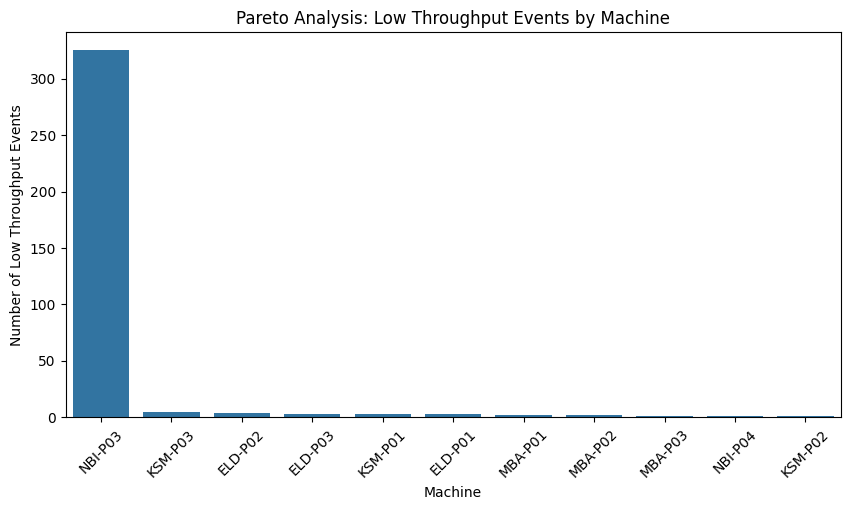

In [53]:
fig, ax1 = plt.subplots(figsize=(10,5))

sns.barplot(
    data=machine_pareto,
    x="machine_id",
    y="problem_count",
    ax=ax1
)

ax1.set_title(
    "Pareto Analysis: Low Throughput Events by Machine"
)

ax1.set_xlabel("Machine")
ax1.set_ylabel("Number of Low Throughput Events")

plt.xticks(rotation=45)

plt.show()

In [54]:
incident_pareto = (
    low_throughput["incident_type"]
    .value_counts()
    .reset_index()
)

incident_pareto.columns = [
    "incident_type",
    "problem_count"
]